# 基于 vLLM 的视觉语言模型 OCR 教程
---
## 概述

本 Notebook 提供分步指南，演示如何结合 **视觉语言模型（Vision-Language Model, VLM）**、**vLLM** 与 **Gradio**，构建一套可用于推理的光学字符识别（Optical Character Recognition, OCR）系统。

OCR 是从图像、扫描文档及手写内容中提取文本的关键技术。视觉语言模型基于 Transformer 架构，能够进行上下文感知的文本识别，从而显著增强传统 OCR 能力。

本教程以 LLaVA、BLIP-2、Qwen-VL 等模型为例，讲解 OCR 场景的实践方法，主要涵盖：

- 基于 Docker 与 ROCm 的环境配置
- 在容器内启动 Jupyter Notebook
- 安装依赖
- 使用 vLLM 构建 OCR 推理流程
- 扩展为支持多模型选择的图形界面（GUI）系统

本教程采用 **vLLM** 作为大语言模型（Large Language Model, LLM）推理引擎。vLLM 通过高效请求批处理（batching）与 GPU 资源调度，优化文本生成工作负载，实现高吞吐、低延迟，适用于聊天机器人等交互式应用。

---


## 前置条件

宿主机查询操作系统

### 操作系统

- **Ubuntu 24.04.4 LTS**。使用命令查询os的版本:cat /etc/os-release，我使用的是Ubuntu 24.04.4。Radeon 上的 ROCm 7.2.x 目前仅支持 Ubuntu 24.04.4、Ubuntu 22.04.5、RHEL 10.1、RHEL 9.7。
- ![image.png](attachment:229c929b-7cb4-4398-88c0-93a77c0dd9e7.png)

### 硬件

- **AMD Radeon AI PRO R9700**：本教程在 **AMD Radeon AI PRO R9700**（RDNA4，gfx1201，32GB 显存）上完成测试。其他受支持型号包括 RX 7900 XT / GRE、RX 9070 XT / GRE / 9070、RX 9060 XT、PRO W7900 / W7800 等。请确认你的卡在 ROCm Radeon 兼容性矩阵 内。(https://rocm.docs.amd.com/projects/install-on-linux/en/latest/reference/system-requirements.html)。
- 只能在**容器里**使用该命令查询当前使用的GPU架构代号：rocminfo | grep -E 'Name:|Marketing Name:|Device Type:|gfx'

In [1]:
!rocminfo | grep -E 'Name:|Marketing Name:|Device Type:|gfx'

  Name:                    AMD Ryzen Threadripper PRO 9995WX 96-Cores
  Marketing Name:          AMD Ryzen Threadripper PRO 9995WX 96-Cores
  Vendor Name:             CPU                                
  Device Type:             CPU                                
  Name:                    gfx1201                            
  Marketing Name:          AMD Radeon Graphics                
  Vendor Name:             AMD                                
  Device Type:             GPU                                
      Name:                    amdgcn-amd-amdhsa--gfx1201         
      Name:                    amdgcn-amd-amdhsa--gfx12-generic   
  Name:                    gfx1201                            
  Marketing Name:          AMD Radeon Graphics                
  Vendor Name:             AMD                                
  Device Type:             GPU                                
      Name:                    amdgcn-amd-amdhsa--gfx1201         
      Name:                  

### 软件

- **ROCm 7.2.4**：按 [ROCm 安装指南](https://rocm.docs.amd.com/projects/install-on-linux/en/latest/install/quick-start.html) 安装并验证。安装完成后，执行以下命令确认环境,该命令将列出 AMD GPU 及相关详细信息：
  > **说明**：若使用 ROCm 6.4 及更早版本，请改用 `rocm-smi` 命令。

In [6]:
!amd-smi

+------------------------------------------------------------------------------+
| AMD-SMI 26.2.2+97f5574fe2    amdgpu version: 6.17.0-35 ROCm version: 7.2.4    |
| VBIOS version: 023.008.000.068.000001                                        |
| Platform: Linux Baremetal                                                    |
|-------------------------------------+----------------------------------------|
| BDF                        GPU-Name | Mem-Uti   Temp   UEC       Power-Usage |
| GPU  HIP-ID  OAM-ID  Partition-Mode | GFX-Uti    Fan               Mem-Usage |
|=====================================+========================================|
| 0000:03:00.0    AMD Radeon Graphics | 0 %      48 °C   0            30/300 W |
|   0       1     N/A             N/A | 1 %     20.0 %             57/30576 MB |
|-------------------------------------+----------------------------------------|
| 0000:23:00.0    AMD Radeon Graphics | 0 %      41 °C   0            24/300 W |
|   1       2     N/A      

- **Docker**：确保 Docker 已正确安装与配置。请参照对应操作系统的 Docker 安装文档:https://docs.docker.com/engine/install/ubuntu/。
  > **说明**: 进入ontebook上的terminal就直接进入容器了

  > **说明**：请正确配置 Docker 权限。若需允许非 root 用户访问 Docker，如下操作:
  
  > **说明**：root用户登录宿主机:
  
  sudo usermod -aG docker **个人用户名**    # 把 个人用户名 加进 docker 组(需要 root/sudo)
  > **说明**：个人用户登录宿主机：
  
  newgrp docker       #目的是让普通用户能够免 sudo 直接使用 docker。
  
  验证 Docker 是否正常工作：
  ```bash
  docker run hello-world
  ```

> **说明**:可通过该命令systemd-detect-virt查询是否在docker里面,结果返回docker,说明在docker里面.

In [7]:
!systemd-detect-virt

docker


## 一. **宿主机**上创建 Docker

    创建+启动 Docker 容器：

```bash
docker run -d -it \
  --name OCR_rocm7.2.4 \
  --device=/dev/kfd \
  --device=/dev/dri \
  --group-add video \
  --cap-add=SYS_PTRACE \
  --security-opt seccomp=unconfined \
  --ipc=host \
  --shm-size=16g \
  -v "$HOME/OCR_rocm7.2.4:/workspace" \
  -w /workspace \
  -p 8888:8888 \
  --env MODELSCOPE_CACHE=/workspace/modelscope \
  rocm/pytorch:rocm7.2.4_ubuntu24.04_py3.12_pytorch_release_2.10.0 \
  bash 
```

进容器跑一下 python -c "import torch; print(torch.cuda.is_available())" 验证一下：返回 True,说明GPU可以获取。
```
docker exec -it <容器名/ID> bash     #进入容器
```
> **说明**：上述命令-w将当前目录挂载至容器内 `/workspace`。
  
> -p 8888:8888冒号右边容器内的端口映射到冒号左边宿主机端口。
> 
> 我使用的是宿主机上的镜像，也可以使用主分支下的rocm/vllm-dev:main，它是 Docker Hub 上的镜像坐标，从镜像仓库https://hub.docker.com/r/rocm/vllm-dev  拉取的。


## 二. 在**容器内**启动 Jupyter Notebook

在 Docker 容器内安装 Jupyter,正常情况下Notebook已经装了Jupyter，可先判断是否已经安装，!pip list | grep Jupyter,若能查询出结果表示已经安装：

In [ ]:
!pip install jupyter

### 安装jupyter-server-proxy
jupyter-server-proxy 的作用是：让 Jupyter（8888）帮 Gradio 转发流量——你访问 8888 上的一个子路径，Jupyter 在容器内部把请求转给 7860 的 Gradio。当初创建容器只映射了8888端口，直接复用 8888 这条已经通的路。

In [ ]:
!pip install jupyter-server-proxy

![image.png](attachment:6c0bd087-4fae-4fc0-8322-5c9c2c14ca64.png)

启动 Jupyter 服务：
> **说明**：运行前请确认端口 `8888` 未被占用。若已占用，可将 `--port=8888` 替换为其他端口，例如 `--port=8890`。

> **注意**： 1.为什么要在容器内启动 Jupyter? 目的是用浏览器打开Jupyter在网页里写代码、点运行，Jupyter 只是编辑器 + 运行按钮。
> 
>            2.查看端口是否被占用? grep ':22B8 ' /proc/net/tcp /proc/net/tcp6 2>/dev/null，返回22B8说明8888端口被占用，8888 的十六进制是 22B8。这里我不想安装ss或者netstat，所以直接用这种查询方式。
> 
>            3.Jupyter 是否已启动？ps aux | grep -E 'jupyter|jupyter-lab|jupyterlab'，返回有 jupyter-lab 或 jupyter notebook 进程，说明在跑。


In [ ]:
!jupyter-lab --ip=0.0.0.0 --port=8888 --no-browser --allow-root

Jupyter 启动后上传。请保存终端输出的 Token 或 URL，以便在浏览器中访问 Notebook。
http://127.0.0.1:8888/lab?token=xxxxx  
通过该链接访问Notebook。
![image.png](attachment:f8adad6e-3949-489c-85c4-7ee26829c384.png)

## 三.下载模型
本教程使用 Qwen2-VL-2B-Instruct。
- 下面用 ModelScope（魔搭社区） 下载，国内访问速度快、稳定，无需token验证。https://modelscope.cn/models/Qwen/Qwen2-VL-2B-Instruct
- 把权重下载到/workspace/modelscope/models/Qwen2-VL-2B-Instruct下。

!pip install modelscope
modelscope download --model Qwen/Qwen2-VL-2B-Instruct --local_dir /workspace/modelscope/models/Qwen2-VL-2B-Instruct

### modelscope一般优先下载json文件，最后下载2个safetensors文件且比较大，我下载大概需要5个小时，但是可以使用其他方法快速下载该文件。
   - model-00001-of-00002.safetensors
   - model-00002-of-00002.safetensors
     
workround方法，**aria2c** 多连接直拉,参考使用：
> 安装aria2

apt update && apt install -y aria2

> 装完再跑测速命令：

aria2c -x 16 -s 16 "https://hf-mirror.com/Qwen/Qwen2-VL-2B-Instruct/resolve/main/model-00002-of-00002.safetensors" -o /tmp/speedtest.bin

我测出的速度是57MiB/S,比我使用modelscope快好多倍。
![image.png](attachment:c501c445-d5fe-446a-935b-c1514d6f4d6e.png)

cd /workspace/modelscope/models/Qwen/Qwen2-VL-2B-Instruct

BASE=https://hf-mirror.com/Qwen/Qwen2-VL-2B-Instruct/resolve/main

> 下载主权重 3.71G

aria2c -x 16 -s 16 -c "$BASE/model-00001-of-00002.safetensors" -o model-00001-of-00002.safetensors

>下载第二个分片 409M

aria2c -x 16 -s 16 -c "$BASE/model-00002-of-00002.safetensors" -o model-00002-of-00002.safetensors
  

## 四. 安装依赖

在容器内的 Jupyter Notebook 中执行以下命令，安装本教程所需库,可先查询是否已经安装：!pip list|grep requests：

In [10]:
!pip list|grep requests

requests                                 2.34.2


In [2]:
!pip install gradio

![image.png](attachment:b860c2b7-3f7f-4a3c-94d9-9226521810dc.png)

在当前 Notebook 的 Python 环境里需装上 ROCm 版的 vLLM。注意一个关键点：不能直接 pip install vllm，因为 PyPI 默认是 CUDA 版，在 AMD 上要么装错、要么跑不起来。
先查清楚环境，要求torch必须是ROCm版,需满足如torch: 2.10.0+rocm7.2.4.git3d3aa833； ROCm 下这个接口必须返回 True，torch.cuda.is_available()。

In [4]:
import sys
print("python:", sys.executable)
# ROCm 版本
import subprocess
print(subprocess.run(["bash","-c","cat /opt/rocm/.info/version 2>/dev/null || echo unknown"],
                     capture_output=True, text=True).stdout)
# torch 是不是 ROCm 版
try:
    import torch
    print("torch:", torch.__version__)        # ROCm 版会带 +rocm 后缀
    print("gpu available:", torch.cuda.is_available())
    print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
except Exception as e:
    print("torch error:", e)

python: /opt/venv/bin/python
7.2.4

torch: 2.10.0+rocm7.2.4.git3d3aa833
gpu available: True
device: AMD Radeon Graphics


In [7]:
!python3 --version

Python 3.12.3


In [ ]:
!pip install vllm==0.23.0+rocm723 \
  --extra-index-url https://wheels.vllm.ai/rocm/0.23.0/rocm723 \
  --break-system-packages

![image.png](attachment:2ec0cb23-6298-4954-8adc-809ccedabfe8.png)

安装vllm后确认torch的版本是否被覆盖安装

In [9]:
import sys
print("python:", sys.executable)
# ROCm 版本
import subprocess
print(subprocess.run(["bash","-c","cat /opt/rocm/.info/version 2>/dev/null || echo unknown"],
                     capture_output=True, text=True).stdout)
# torch 是不是 ROCm 版
try:
    import torch
    print("torch:", torch.__version__)        # ROCm 版会带 +rocm 后缀
    print("gpu available:", torch.cuda.is_available())
    print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
except Exception as e:
    print("torch error:", e)

python: /opt/venv/bin/python
7.2.4

torch: 2.10.0+rocm7.2.4.git3d3aa833
gpu available: True
device: AMD Radeon Graphics


In [11]:
!pip list|grep vllm

vllm                                     0.23.0+rocm723


## 五. 使用 vLLM 构建 OCR 系统

首先定义 `ImageInference` 推理类。该类通过构造函数初始化推理模型，并提供对输入图像执行推理的方法。

```
先查询下当前的所在目录

In [1]:
import os
print(os.getcwd())

/workspace


In [1]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer
from PIL import Image
from vllm.multimodal.utils import fetch_image
import sys

current_model = "modelscope/models/Qwen2-VL-2B-Instruct"
class ImageInference:
    def __init__(self, model_name=current_model):
        # Initialize the model and tokenizer
        self.llm = LLM(model=model_name, max_model_len=4096, max_num_seqs=16, enforce_eager=True)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    def generate_image_output(self, image: Image) -> str:
        messages = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": (
                    "Act as an OCR assistant. Analyze the provided image and:\n"
                    "1. Identify and transcribe all visible text in the image exactly as it appears.\n"
                    "2. Preserve the original line breaks, spacing, and formatting from the image.\n"
                    "3. Output only the transcribed text, line by line, without adding any commentary or explanations or special characters.\n"
                )},
            ],
        }]
        prompt = self.tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
    
        sampling_params = SamplingParams(max_tokens=512, temperature=0.0)
    
        outputs = self.llm.generate({
            "prompt": prompt,
            "multi_modal_data": {"image": image},
        }, sampling_params=sampling_params)
    
        return outputs[0].outputs[0].text if outputs else "No output generated."

### 测试 OCR 系统

执行以下命令下载[测试图像](https://github.com/ROCm/gpuaidev/tree/main/docs/notebooks/assets/together_we_advance_.png)：

In [4]:
import requests

url = "https://raw.githubusercontent.com/ROCm/gpuaidev/main/docs/notebooks/assets/together_we_advance_.png"
filename = "together_we_advance_.png"

response = requests.get(url)
with open(filename, "wb") as file:
    file.write(response.content)

print("Download complete:", filename)

Download complete: together_we_advance_.png


读取并预览图像：

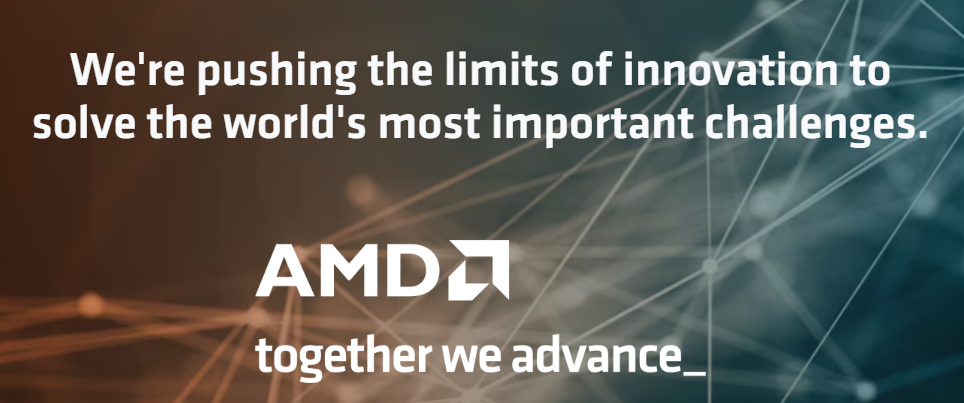

In [2]:
pil_image = Image.open("together_we_advance_.png")
pil_image = pil_image.convert("RGB")  # Ensure the image is in RGB format
pil_image

初始化 `ImageInference` 实例：

In [ ]:
inference = ImageInference()

将图像传入模型进行推理并打印结果：

In [4]:
# Generate output for the image
output = inference.generate_image_output(pil_image)

# Print the result
print("Model Output:")
print(output)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|      | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

(EngineCore pid=7563) WARNING 06-14 12:09:39 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _compute_slot_mapping_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=7563) WARNING 06-14 12:09:39 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _triton_mrope_forward. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=7563) WARNING 06-14 12:09:40 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _fwd_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Processed prompts: 100%|█| 1/1 [00:02<00:00,  2.63s/it, est. speed input: 215.41 toks/s, output: 8.75 to

Model Output:
We're pushing the limits of innovation to solve the world's most important challenges.

AMD

together we advance


恭喜您！您刚刚成功构建了一个 OCR 系统。创建一个能够转录给定图像中文字内容的 OCR 系统其实非常简单。

## 六. 扩展为支持多模型选择的 GUI 系统

为聊天机器人提供图形界面，可使用 **Gradio** 构建交互式 Web UI。

### 导入 Gradio 并定义可选 VLM 模型列表

以下代码预置了若干可用于图像分析的模型。完整支持列表见 [vLLM 官方文档](https://docs.vllm.ai/en/latest/models/supported_models.html)。

In [7]:
import gradio as gr

# Define available models and their Hugging Face model IDs
MODEL_OPTIONS = {
    "Llama-3.2-11B-Vision-Instruct": "meta-llama/Llama-3.2-11B-Vision-Instruct",
    "BLIP-2 (2.7B)": "Salesforce/blip2-opt-2.7b",
    "BLIP-2 (6.7B)": "Salesforce/blip2-opt-6.7b",
    "Fuyu (8B)": "adept/fuyu-8b",
    "GLM-4V (9B)": "THUDM/glm-4v-9b",
    "H2OVL Mississippi (2B)": "h2oai/h2ovl-mississippi-2b",
    "H2OVL Mississippi (800M)": "h2oai/h2ovl-mississippi-800m",
    "InternVL2 (4B)": "OpenGVLab/InternVL2-4B",
    "InternVL2 (2B)": "OpenGVLab/Mono-InternVL-2B",
    "LLaVA 1.5 (7B)": "llava-hf/llava-1.5-7b-hf",
    "LLaVA 1.5 (13B)": "llava-hf/llava-1.5-13b-hf",
    "MiniCPM-V (2_5)": "openbmb/MiniCPM-Llama3-V-2_5",
    "MiniCPM-V (2)": "openbmb/MiniCPM-V-2",
    "Molmo (7B)": "allenai/Molmo-7B-D-0924",
    "PaliGemma (3B PT)": "google/paligemma-3b-pt-224",
    "PaliGemma (3B Mix)": "google/paligemma-3b-mix-224",
    "Phi-3 Vision (128K)": "microsoft/Phi-3-vision-128k-instruct",
    "Phi-3.5 Vision": "microsoft/Phi-3.5-vision-instruct",
    "Pixtral (12B)": "mistralai/Pixtral-12B-2409",
    "Qwen-VL": "Qwen/Qwen-VL",
    "Qwen-VL-Chat": "Qwen/Qwen-VL-Chat",
    "Qwen2-VL (2B)": "Qwen/Qwen2-VL-2B-Instruct",
    "Qwen2-VL (7B)": "Qwen/Qwen2-VL-7B-Instruct",
}

### 创建 Gradio 界面

定义模型切换与图像推理两个辅助函数，并构建 Gradio Blocks 界面：

In [8]:
def switch_model(model_name):
    global inference
    try:
        inference = ImageInference(model_name=model_name)
        return f"Switched to model: {model_name}"
    except Exception as e:
        return f"Failed to switch model: {str(e)}"

def analyze_image(image):
    try:
        pil_image = image.convert("RGB")
        result = inference.generate_image_output(pil_image)
        return result
    except Exception as e:
        return f"Error processing the image: {str(e)}"

with gr.Blocks() as interface:
    gr.Markdown("## Multimodal OCR & Image Analysis")
    
    with gr.Row():
        model_dropdown = gr.Dropdown(
            choices=list(MODEL_OPTIONS.keys()),
            value="Llama-3.2-11B-Vision-Instruct",
            label="Select Model",
        )
        switch_button = gr.Button("Switch Model")

    model_status = gr.Textbox(value=f"Current Model: {current_model}", label="Model Status")

    image_input = gr.Image(type="pil", label="Upload Image")
    analyze_button = gr.Button("Analyze Image")
    # output_box = gr.Textbox(label="Model Output", lines=10)
    output_box = gr.Markdown(label="Model Output")

    switch_button.click(
        fn=lambda selected_model: (switch_model(MODEL_OPTIONS[selected_model]), f"Current Model: {MODEL_OPTIONS[selected_model]}"),
        inputs=[model_dropdown],
        outputs=[model_status, model_status],
    )
    analyze_button.click(fn=analyze_image, inputs=image_input, outputs=output_box)

### 运行 Gradio 应用
执行以下代码启动 GUI。
```
server_name="127.0.0.1"：Gradio 只在容器内部监听本地回环。因为外部访问由 Jupyter 代理转发进来，Gradio 自己不需要对外暴露，绑本地即可。
```
```
server_port=7860：Gradio 实际监听的端口。Jupyter 代理要把请求转到这个端口，所以它和 URL 里 /proxy/7860 的数字必须一致。
```
```
root_path="/proxy/7860"：告诉 Gradio "你不是跑在根路径 /，而是挂在 /proxy/7860/ 下面"。
```

In [10]:
interface.launch(server_name="127.0.0.1", server_port=7860, root_path="/proxy/7860")

Task was destroyed but it is pending!
task: <Task pending name='Task-210' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-211' coro=<Kernel.shell_main() running at /opt/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/venv/lib/python3.12/site-packages/fastapi/routing.py:351: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def get_request_handler(
Task was destroyed but it is pending!
task: <Task pending name='Task-211' coro=<Kernel.shell_main() running at /opt/venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
* To create a public link, set `share=True` in `launch()`.


/opt/venv/lib/python3.12/site-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|█| 1/1 [00:00<00:00,  5.66it/s, est. speed input: 3219.20 toks/s, out


```
在浏览器中访问http://127.0.0.1:8888/proxy/7860/，
可直接与 OCR 系统交互：   
选择模型上传图片，点击Analyze Image解析图片
```
![image.png](attachment:8f07a355-95e2-4432-a407-db375e25ffc3.png)

## 七. 进阶实验：升级到更高质量的 OCR 模型（可选）

本教程主路径用的是轻量快速的 **Qwen2-VL-2B-Instruct**，印刷体 OCR 够用、显存最省。如果你想要更高的识别准确率（多语种、表格、手写、公式、长文档版面），可在本卡 **32GB 显存** 预算内按下表升级。模型权重与加载配置都不同：

| 模型 | 说明 | 显存建议（R9700 / 32GB） | 工作流 |
|------|------|------|------|
| `Qwen2-VL-2B-Instruct`（本教程） | 最轻量，最快，常规印刷体 OCR 够用 | ~6–10GB | 教程默认流程 |
| `Qwen2-VL-7B-Instruct` | 同架构直接升级，多语种 / 表格更稳，32GB 可跑 bf16 全量 | ~18–24GB | 仅替换 `current_model`，prompt 模板不变 |
| `Qwen2.5-VL-7B-Instruct`（推荐） | OCR 准确率明显优于 2B，文档 / 手写 / 公式更好 | ~20–26GB | 同上，需较新 `transformers`，先确认 vLLM wheel 支持 |
| `OpenGVLab/InternVL2_5-8B` | 文档版面与长文本理解强，复杂排版表现好 | ~20–26GB | 需按模型卡改 prompt 与图像分块（与 Qwen 写法不同） |
| `Qwen2.5-VL-72B-Instruct`（-AWQ） | OCR 天花板，复杂版面 / 公式 | AWQ≈40GB+，**超出 32GB** | 本卡单卡放不下，需多卡或更大显存，不建议本环境 |

> **先软件、后硬件**：换更大模型前，先用软件手段在 32GB 内压显存——量化权重（AWQ/GPTQ）、调低 `max_model_len`（如 4096→2048）、调低 `max_num_seqs`。这些都不够再考虑换更大显存的卡。
>
> **环境专用，禁止跨环境推断**：上表是按 OCR 质量与 32GB 预算给的候选，并非都已在本环境（Radeon **gfx1201** + ROCm **7.2.4** + vLLM **0.23.0+rocm723**）逐一验证。升级前请先确认该模型在当前 vLLM wheel 上受支持，再按「三. 下载模型」的方式把权重下到本地 `modelscope/models/<模型名>` 下。

### 实验：同一张图横向对比不同模型

下面的代码用同一张测试图（`pil_image`），依次加载若干模型并打印识别结果与加载 / 推理耗时，方便你在 32GB 预算下横向比较准确率与速度。

> **重要**：32GB 卡务必**逐个**模型跑，每次只保留一个 `LLM` 实例，否则会显存不足（OOM）。下面用到的模型需先按「三. 下载模型」下到本地，再把本地路径填进 `EXPERIMENT_MODELS`。该实验复用前面定义的 `ImageInference` 类与 `pil_image` 测试图。

In [ ]:
import time, gc, torch

# 升级模型先下到本地，例如：
#   modelscope download --model Qwen/Qwen2-VL-7B-Instruct \
#       --local_dir modelscope/models/Qwen2-VL-7B-Instruct
# 未下载的可先注释掉，避免加载报错。
EXPERIMENT_MODELS = {
    "Qwen2-VL-2B (本教程)": "modelscope/models/Qwen2-VL-2B-Instruct",
    "Qwen2-VL-7B":          "modelscope/models/Qwen2-VL-7B-Instruct",
    "Qwen2.5-VL-7B":        "modelscope/models/Qwen2.5-VL-7B-Instruct",
}

def run_ocr_benchmark(name, model_path, image):
    print(f"\n===== {name}  ({model_path}) =====")
    t0 = time.time()
    infer = ImageInference(model_name=model_path)   # 加载模型
    load_s = time.time() - t0

    t1 = time.time()
    text = infer.generate_image_output(image)       # 执行 OCR
    infer_s = time.time() - t1

    print(f"加载耗时: {load_s:.1f}s | 推理耗时: {infer_s:.1f}s")
    print("识别结果:\n" + text)

    # 释放显存，便于继续加载下一个模型
    del infer
    gc.collect()
    torch.cuda.empty_cache()

for name, path in EXPERIMENT_MODELS.items():
    run_ocr_benchmark(name, path, pil_image)

> **说明**：上面三个模型同属 Qwen2/2.5-VL 系列，prompt 模板与图像占位符一致，所以可直接复用 `ImageInference` 而无需改代码。若改用 `InternVL2_5-8B` 等其他系列，需参照其模型卡调整 `generate_image_output` 里的 `messages` 写法与图像预处理。

完成对比后，建议在你**实际的数据**（票据、表格、手写、扫描件）上重复该实验，结合显存占用与延迟，选出 32GB 内性价比最高的模型，再把它写回第五节的 `current_model` 与第六节 `MODEL_OPTIONS`，作为生产默认值。

## 课后测验

**第 1 题：** 在 **AMD Radeon + Linux** 上为本教程安装 vLLM 时，为什么不能直接执行 `pip install vllm`？

- A. PyPI 上根本没有 `vllm` 这个包
- B. PyPI 默认装的是 **CUDA 版**，在 AMD GPU 上要么装错、要么跑不起来，必须用 ROCm 专用 wheel（如 `vllm==0.23.0+rocm723`）
- C. 必须先卸载 PyTorch 才能安装
- D. vLLM 完全不支持 AMD GPU

**第 2 题：** 本教程在容器内安装并使用 `jupyter-server-proxy`，它的主要作用是什么？

- A. 让 Jupyter（`8888`）帮 Gradio 转发流量——访问 `8888` 的子路径，由 Jupyter 在容器内部把请求转给 `7860` 的 Gradio，从而复用已映射的 `8888` 端口
- B. 加速从 ModelScope 下载模型权重
- C. 提升 GPU 的显存利用率
- D. 直接在浏览器里管理 Docker 容器

**第 3 题：** 在 **R9700（32GB 显存）** 上想提升 OCR 准确率、要换更大的模型，下面哪种做法符合"先软件、后硬件"原则？

- A. 直接换成 `Qwen2.5-VL-72B-Instruct`
- B. 立即换一张显存更大的卡
- C. 先用软件手段在 32GB 内压显存——权重量化（AWQ/GPTQ）、调低 `max_model_len`（如 4096→2048）、调低 `max_num_seqs`，这些都不够再考虑换卡
- D. 直接上多卡并行

**第 4 题：** 在 32GB 单卡上做"同一张图横向对比多个模型"的实验时，正确做法是？

- A. 同时加载所有模型一起跑，方便对比
- B. **逐个**加载模型，每次只保留一个 `LLM` 实例，用完 `del` 并 `gc.collect()` + `torch.cuda.empty_cache()` 释放显存，避免 OOM
- C. 一次性加载越多模型越快
- D. 不需要释放显存，Python 会自动处理

<details>
<summary><b>点击查看答案与解析</b></summary>

1. **B**。AMD 官方推荐从 ROCm 专用 wheel 安装（本教程用 `pip install vllm==0.23.0+rocm723 --extra-index-url https://wheels.vllm.ai/rocm/0.23.0/rocm723`）。PyPI 默认的是 CUDA 版，在 AMD GPU 上装错或无法运行；且要求 `torch` 是 ROCm 版（带 `+rocm` 后缀、`torch.cuda.is_available()` 返回 `True`）。

2. **A**。创建容器时只映射了 `8888` 端口，`jupyter-server-proxy` 让 Jupyter 把对 `8888` 子路径的请求转发到容器内 `7860` 的 Gradio，因此无需再额外开放端口，直接复用已通的 `8888`（访问 `http://127.0.0.1:8888/proxy/7860/`）。

3. **C**。框架强调"软件优化优先于硬件升级"：先用量化、调低 `max_model_len` 和 `max_num_seqs` 等软件手段在 32GB 内压显存；确实不够时才换更大显存的卡。直接换 72B（AWQ≈40GB+）会超出 32GB，单卡放不下。

4. **B**。32GB 卡务必逐个模型跑，每次只保留一个 `LLM` 实例，并在用完后 `del` + `gc.collect()` + `torch.cuda.empty_cache()` 释放显存，否则同时加载多个模型会显存不足（OOM）。

</details>
